# 內積（Dot Product / Inner Product）：代數、幾何，與兩者為何相等

這份筆記整理了一段關於內積的討論，主軸是一個常被忽略的事實：**代數定義與幾何定義不是兩個東西，而是同一個運算的兩種視角**，而且可以證明它們恆等。

內容順序：

1. 代數定義（對應分量相乘相加）
2. 幾何定義（投影 × 長度）與相似度視角
3. 為什麼兩者相等：兩種證明（差角餘弦、餘弦定理）
4. 數字驗算與隨機向量檢驗
5. 幾何視覺化（向量、夾角、投影）
6. 投影隨夾角變化 + 與注意力機制（attention）的連結

執行環境只需要 `numpy` 與 `matplotlib`。

## 1. 代數定義

把兩個向量「對應位置的分量相乘，再加總」，結果是一個**純量**（不是向量）：

$$\mathbf{a}\cdot\mathbf{b} = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n = \sum_{i=1}^{n} a_i b_i$$

例如 $\mathbf{a}=(1,2,3)$、$\mathbf{b}=(4,5,6)$：

$$1\times4 + 2\times5 + 3\times6 = 4+10+18 = 32$$

In [1]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("對應分量相乘 a*b :", a * b)        # [ 4 10 18 ]
print("加總 sum(a*b)    :", np.sum(a * b)) # 32
print("np.dot(a, b)     :", np.dot(a, b))  # 32
print("a @ b            :", a @ b)         # 32（@ 是內積運算子）

對應分量相乘 a*b : [ 4 10 18]
加總 sum(a*b)    : 32
np.dot(a, b)     : 32
a @ b            : 32


## 2. 幾何定義與相似度視角

$$\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta$$

其中 $\theta$ 是兩向量的夾角。這個式子揭露內積真正量度的東西：**一個向量在另一個方向上的投影量，再乘上長度**。

從中可以直接讀出直覺：

- 同方向 $\cos\theta=1$ → 內積最大（正且大）
- 垂直 $\cos\theta=0$ → 內積為零（這就是「正交 orthogonal」的定義）
- 反方向 $\cos\theta=-1$ → 內積為負

### 與相似度的關係（要小心一個細節）

把內積拆開看：

$$\mathbf{a}\cdot\mathbf{b} = \underbrace{\|\mathbf{a}\|\,\|\mathbf{b}\|}_{\text{長度}} \times \underbrace{\cos\theta}_{\text{方向相似度}}$$

純粹的「相似度」其實只藏在 $\cos\theta$ 那一項。原始內積是**被長度加權過的相似度**——一個方向很一致但很短的向量，內積分數可能輸給方向沒那麼一致、但很長的向量。要得到乾淨的相似度，得先正規化把長度除掉，那才是 cosine similarity。

In [2]:
import numpy as np

def cosine_sim(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

a = np.array([np.sqrt(3), 1.0])
b = np.array([0.0, 3.0])

print("原始內積 a·b      :", a @ b)               # 3   被長度加權的相似度
print("cosine similarity :", cosine_sim(a, b))    # 0.5 純方向相似度 = cos60°
print("夾角 θ            :", np.degrees(np.arccos(cosine_sim(a, b))), "度")

原始內積 a·b      : 3.0
cosine similarity : 0.5000000000000001
夾角 θ            : 59.99999999999999 度


## 3. 為什麼兩者相等

「為什麼相等」有好幾種證法。下面給兩個最能看出緣由的。

### 證法一：二維極座標——等價性其實就是「差角餘弦公式」

任何二維向量都能用「長度 + 與 x 軸的夾角」表示。設 $\mathbf{a}$ 與 x 軸夾角 $\alpha$、$\mathbf{b}$ 與 x 軸夾角 $\beta$，則兩者夾角 $\theta=\beta-\alpha$：

$$\mathbf{a} = \big(\|\mathbf{a}\|\cos\alpha,\; \|\mathbf{a}\|\sin\alpha\big), \qquad
  \mathbf{b} = \big(\|\mathbf{b}\|\cos\beta,\; \|\mathbf{b}\|\sin\beta\big)$$

用**代數定義**（對應分量相乘相加）去算：

$$\mathbf{a}\cdot\mathbf{b}
= \|\mathbf{a}\|\|\mathbf{b}\|\big(\cos\alpha\cos\beta + \sin\alpha\sin\beta\big)
= \|\mathbf{a}\|\|\mathbf{b}\|\cos(\beta-\alpha)
= \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$$

括號裡那一串正是三角恆等式 $\cos(\beta-\alpha)=\cos\alpha\cos\beta+\sin\alpha\sin\beta$。代數式就這樣自己長成了幾何式。

**洞見**：$\sum a_i b_i$ 之所以知道兩向量的夾角，是因為把分量拆成極座標後，那些乘積加總起來剛好把兩個各自的角度「相減」成它們之間的夾角。

### 證法二：餘弦定理——適用任意維度

高維沒有單一的「與 x 軸的夾角」，改用餘弦定理。把 $\mathbf{a}$、$\mathbf{b}$、$\mathbf{a}-\mathbf{b}$ 看成三角形三邊，夾在 $\mathbf{a},\mathbf{b}$ 間的角是 $\theta$：

$$\|\mathbf{a}-\mathbf{b}\|^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta \tag{$\star$}$$

另一方面，左邊用座標展開（畢氏／距離公式）：

$$\|\mathbf{a}-\mathbf{b}\|^2 = \sum_i (a_i-b_i)^2 = \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\sum_i a_i b_i \tag{$\star\star$}$$

把 $(\star)$ 與 $(\star\star)$ 對同一條邊 $\|\mathbf{a}-\mathbf{b}\|^2$ 畫等號，兩邊的 $\|\mathbf{a}\|^2+\|\mathbf{b}\|^2$ 相消、$-2$ 約掉：

$$\sum_i a_i b_i = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$$

**接縫**：讓「幾何邊」（餘弦定理）和「代數邊」（座標距離展開）去描述同一條邊。這條邊只有一個長度，兩種算法必須相等，等價性就被逼出來了。

## 4. 數字驗算

取 $\mathbf{a}=(\sqrt3,\,1)$、$\mathbf{b}=(0,\,3)$。

為了不淪為循環論證，夾角 $\theta$ 用 `atan2` 從「各自與 x 軸的夾角」**獨立**算出（呼應證法一），而不是從內積反推。

In [3]:
import numpy as np

a = np.array([np.sqrt(3), 1.0])
b = np.array([0.0, 3.0])

# 代數定義
alg = a[0]*b[0] + a[1]*b[1]

# 幾何定義：θ 用 atan2 獨立取得（非循環）
norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
alpha = np.arctan2(a[1], a[0])   # a 與 x 軸夾角 = 30°
beta  = np.arctan2(b[1], b[0])   # b 與 x 軸夾角 = 90°
theta = beta - alpha             # = 60°
geo = norm_a * norm_b * np.cos(theta)

print(f"|a| = {norm_a:.4f}, |b| = {norm_b:.4f}, θ = {np.degrees(theta):.1f}°")
print(f"代數定義  √3·0 + 1·3      = {alg:.4f}")
print(f"幾何定義  |a||b|cosθ      = {geo:.4f}")
print(f"兩者相等?               {np.isclose(alg, geo)}")

|a| = 2.0000, |b| = 3.0000, θ = 60.0°
代數定義  √3·0 + 1·3      = 3.0000
幾何定義  |a||b|cosθ      = 3.0000
兩者相等?               True


### 隨機向量檢驗

兩個獨立的數值檢驗，分別對應上面兩個證法：

- **2D**：用 `atan2` 取角度算幾何內積，和代數內積比對（證法一）。
- **n 維**：驗證恆等式 $\|\mathbf{a}-\mathbf{b}\|^2 = \|\mathbf{a}\|^2+\|\mathbf{b}\|^2-2\sum a_i b_i$，也就是證法二代數邊 $(\star\star)$ 的那條接縫。

In [4]:
import numpy as np
rng = np.random.default_rng(0)

# 2D：呼應證法一（角度由 atan2 獨立取得）
a2, b2 = rng.normal(size=2), rng.normal(size=2)
alpha, beta = np.arctan2(a2[1], a2[0]), np.arctan2(b2[1], b2[0])
theta = beta - alpha
geo = np.linalg.norm(a2) * np.linalg.norm(b2) * np.cos(theta)
alg = a2[0]*b2[0] + a2[1]*b2[1]
print(f"2D   幾何 {geo:9.5f}   代數 {alg:9.5f}   相等? {np.isclose(geo, alg)}")

# n 維：呼應證法二的 (⋆⋆) 恆等式
for n in (3, 5, 10):
    an, bn = rng.normal(size=n), rng.normal(size=n)
    lhs = np.sum((an - bn)**2)                    # ||a-b||^2 直接座標展開
    rhs = an@an + bn@bn - 2*np.sum(an*bn)         # |a|^2+|b|^2-2Σa_i b_i
    print(f"{n:2d}D  ||a-b||^2 直接 {lhs:9.4f}   恆等式 {rhs:9.4f}   相等? {np.isclose(lhs, rhs)}")

2D   幾何   0.06666   代數   0.06666   相等? True
 3D  ||a-b||^2 直接    9.9354   恆等式    9.9354   相等? True
 5D  ||a-b||^2 直接   10.0241   恆等式   10.0241   相等? True
10D  ||a-b||^2 直接    7.8920   恆等式    7.8920   相等? True


## 5. 幾何視覺化

把 $\mathbf{a}=(\sqrt3,1)$、$\mathbf{b}=(0,3)$ 畫出來。重點是那條橘色的**投影**：把 $\mathbf{a}$ 沿虛線垂直打到 $\mathbf{b}$ 方向上，影子長度 $=\|\mathbf{a}\|\cos\theta = 2\cos60° = 1$。內積就是這個影子乘上 $\|\mathbf{b}\|=3$，得到 $3$。

這裡 $\mathbf{b}$ 剛好躺在 y 軸上，所以投影同時等於 $\mathbf{a}$ 的 y 分量——這正是代數 $\sqrt3\cdot0+1\cdot3$ 把 x 方向濾掉、只留 y 方向的視覺版本。

（圖內文字用 ASCII/數學符號標示，避免中文字型在不同環境下缺字。）

Matplotlib is building the font cache; this may take a moment.


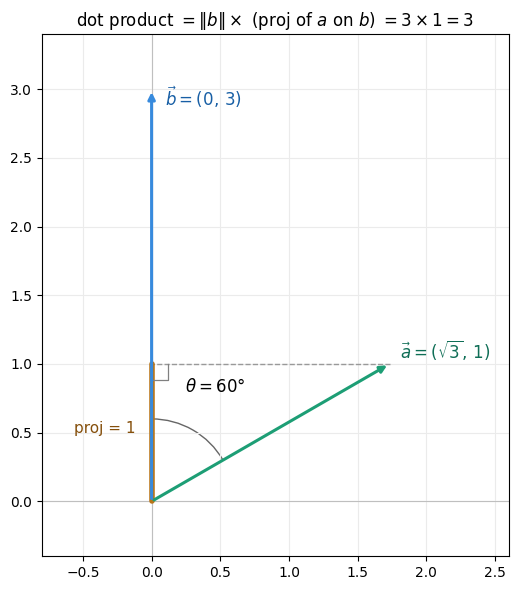

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

a = np.array([np.sqrt(3), 1.0])
b = np.array([0.0, 3.0])

# 投影：a 在 b 上的垂足
foot = (a @ b) / (b @ b) * b           # = (0, 1)
proj_len = (a @ b) / np.linalg.norm(b) # = 1

fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(0, color='0.75', lw=0.8)
ax.axvline(0, color='0.75', lw=0.8)

# 向量 a（綠）、b（藍）
ax.annotate('', xy=a, xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='#1D9E75', lw=2.2))
ax.annotate('', xy=b, xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='#378ADD', lw=2.2))
ax.text(a[0] + 0.08, a[1] + 0.04, r'$\vec a=(\sqrt{3},\,1)$', color='#0F6E56', fontsize=12)
ax.text(b[0] + 0.10, b[1] - 0.12, r'$\vec b=(0,\,3)$', color='#185FA5', fontsize=12)

# a -> 垂足 的虛線（rejection 分量）
ax.plot([a[0], foot[0]], [a[1], foot[1]], ls='--', color='0.6', lw=1)

# 投影段 origin -> 垂足（橘色高亮）
ax.plot([0, foot[0]], [0, foot[1]], color='#BA7517', lw=4, solid_capstyle='round')
ax.text(-0.12, foot[1] / 2, 'proj = 1', color='#854F0B', fontsize=11, ha='right')

# 夾角弧 + 標籤
ang_a = np.degrees(np.arctan2(a[1], a[0]))   # 30
ang_b = np.degrees(np.arctan2(b[1], b[0]))   # 90
ax.add_patch(Arc((0, 0), 1.2, 1.2, angle=0, theta1=ang_a, theta2=ang_b, color='0.4'))
mid = np.radians((ang_a + ang_b) / 2)
ax.text(0.92 * np.cos(mid), 0.92 * np.sin(mid), r'$\theta=60°$', fontsize=12, ha='center')

# 垂足的直角標記
ax.plot([foot[0] + 0.12, foot[0] + 0.12, foot[0]],
        [foot[1], foot[1] - 0.12, foot[1] - 0.12], color='0.5', lw=0.9)

ax.set_aspect('equal')
ax.set_xlim(-0.8, 2.6)
ax.set_ylim(-0.4, 3.4)
ax.grid(True, color='0.92')
ax.set_title(r'dot product $= \|b\|\times$ (proj of $a$ on $b$) $= 3\times1 = 3$', fontsize=12)
plt.tight_layout()
plt.show()

## 6. 投影隨夾角變化，與注意力機制的連結

固定長度 $\|\mathbf{a}\|=2$、$\|\mathbf{b}\|=3$，讓夾角 $\theta$ 從 $0°$ 掃到 $180°$。內積 $=\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$ 會在 $90°$（正交）穿過零，之後翻負——投影翻到反方向。

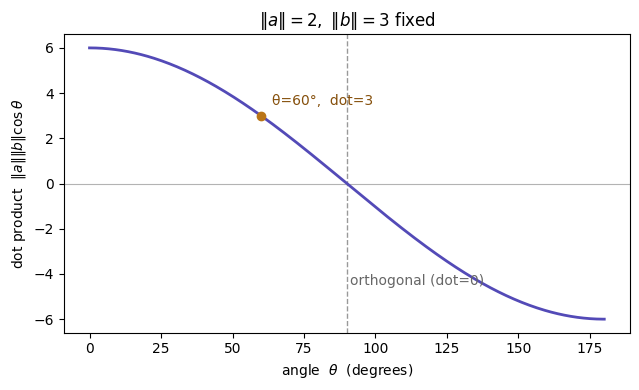

In [6]:
import numpy as np
import matplotlib.pyplot as plt

mag_a, mag_b = 2.0, 3.0
theta = np.linspace(0, np.pi, 400)
dot = mag_a * mag_b * np.cos(theta)

plt.figure(figsize=(6.5, 4))
plt.axhline(0, color='0.7', lw=0.8)
plt.axvline(90, ls='--', color='0.6', lw=1)
plt.plot(np.degrees(theta), dot, color='#534AB7', lw=2)
plt.scatter([60], [3], color='#BA7517', zorder=5)
plt.annotate('θ=60°,  dot=3', (60, 3), textcoords='offset points', xytext=(8, 8),
             color='#854F0B')
plt.text(91, -4.5, 'orthogonal (dot=0)', color='0.4', fontsize=10)
plt.xlabel(r'angle  $\theta$  (degrees)')
plt.ylabel(r'dot product  $\|a\|\|b\|\cos\theta$')
plt.title(r'$\|a\|=2,\ \|b\|=3$ fixed')
plt.tight_layout()
plt.show()

### 回到注意力機制（attention）

Transformer 裡的 $\mathbf{q}\cdot\mathbf{k}$ 就是在高維空間做同一件事：

- **硬體上**算的是 $\sum_i q_i k_i$ 的廉價加總（代數那一側）。
- **幾何上**得到的是 query 與 key 的方向匹配度，被各自的 norm 加權過（幾何那一側）。

注意一個重點：attention 用的是**原始**內積，不是 cosine，所以長度（norm）會影響分數。這也正是為什麼要除以 $\sqrt{d_k}$ 來縮放——維度一高，分量加總出來的內積數值會被推得很大，把 softmax 推進梯度很平的飽和區。那個 $\sqrt{d_k}$ 處理的是「量級」這一面，而不是「方向相似度」那一面。

**一句話總結**：幾何在量「影子 × 長度」，代數在量「對齊的那個分量」，第 3 節的兩個證明保證它們永遠是同一個數字。